# Pass Clustering & Team Playing Style Visualisation + Pass Networks & Centralisation Analysis - BARCELONA  

**Competition Focus:** La Liga - 2015/16 Season  
**Dataset:** StatsBomb Open Data (free event data repository)  
**Purpose:** Build pass clustering visualisations that reveal team playing styles, using event data to identify recurring passing patterns and present them in an intuitive, insight-driven format.  
**Methods:** Feature engineering, unsupervised learning (K-Means clustering), distributional analysis, z-score normalisation, and visualisation using representative pass trajectories.  
**Author:** [Victoria Friss de Kereki](https://www.linkedin.com/in/victoria-friss-de-kereki/)  
**Medium Articles:**  _TBC_

**Notebook first written:** `14/04/2026`  
**Last updated:** `06/05/2026`  

> This notebook presents a step-by-step approach to building pass clustering visualisations using event data from the 2015/16 La Liga season. Each pass is represented by its start and end coordinates and grouped into clusters using K-Means, allowing recurring “pass types” to emerge from the data.  
>
> To make these patterns interpretable at team level, cluster usage is aggregated and compared to league averages using z-scores, highlighting which passing behaviours are over- or under-represented.  
>
> The approach is applied across multiple contexts, including all passes, own half build-up, and defensive third build-up, enabling a structured view of how teams construct possession in different phases of play.  
>
> The objective is not to evaluate performance, but to demonstrate how clustering and visualisation techniques can be combined to better understand and communicate patterns in football data.  

  
---------------------

## 1. Packages and Configuration

In [1]:
# Standard library
import math
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# Football data||
from statsbombpy import sb

# Machine learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Utilities
from tqdm import tqdm

warnings.filterwarnings("ignore", message="credentials were not supplied")

## Check Barcelona Match Data

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Call statsbomb API to get all free competitions, then check Women's comps
free_comps = sb.competitions()
laliga_comps = free_comps[
    (free_comps['competition_gender'] == 'male') & 
    (free_comps['competition_name'] == 'La Liga')
]

laliga_comps

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
38,11,90,Spain,La Liga,male,False,False,2020/2021,2025-01-29T17:39:28.924386,2025-01-29T18:09:18.620699,2025-01-29T18:09:18.620699,2025-01-29T17:39:28.924386
39,11,42,Spain,La Liga,male,False,False,2019/2020,2024-12-16T16:51:06.833054,2021-06-13T16:17:31.694,None,2024-12-16T16:51:06.833054
40,11,4,Spain,La Liga,male,False,False,2018/2019,2024-09-22T18:50:23.364757,2021-07-09T14:53:22.103024,None,2024-09-22T18:50:23.364757
41,11,1,Spain,La Liga,male,False,False,2017/2018,2025-07-14T10:01:16.674864,2021-06-13T16:17:31.694,None,2025-07-14T10:01:16.674864
42,11,2,Spain,La Liga,male,False,False,2016/2017,2025-03-09T16:03:54.962718,2021-06-13T16:17:31.694,None,2025-03-09T16:03:54.962718
43,11,27,Spain,La Liga,male,False,False,2015/2016,2025-04-23T13:59:22.835792,2021-06-13T16:17:31.694,None,2025-04-23T13:59:22.835792
44,11,26,Spain,La Liga,male,False,False,2014/2015,2025-06-24T13:39:01.068680,2021-06-13T16:17:31.694,None,2025-06-24T13:39:01.068680
45,11,25,Spain,La Liga,male,False,False,2013/2014,2025-06-24T09:52:44.048585,2021-06-13T16:17:31.694,None,2025-06-24T09:52:44.048585
46,11,24,Spain,La Liga,male,False,False,2012/2013,2025-06-24T13:53:14.047130,2021-06-13T16:17:31.694,None,2025-06-24T13:53:14.047130
47,11,23,Spain,La Liga,male,False,False,2011/2012,2025-06-24T13:38:10.764259,2021-06-13T16:17:31.694,None,2025-06-24T13:38:10.764259


In [3]:
# Prepare list to store match counts
match_counts = []

# Loop over each competition_id + season_id
for comp_id, season_id in zip(laliga_comps['competition_id'], laliga_comps['season_id']):
    # Count actual matches
    try:
        matches = sb.matches(competition_id=comp_id, season_id=season_id)
        matches_count = len(matches)
    except:
        matches_count = 0

    match_counts.append({
        'competition_id': comp_id,
        'season_id': season_id,
        'matches_count': matches_count
    })

# Convert to DataFrame
match_counts_df = pd.DataFrame(match_counts)

# Join metadata from men_comps
metadata_cols = ['competition_id', 'season_id', 'competition_name', 'season_name',
                 'match_updated', 'match_updated_360', 'match_available_360', 'match_available']
match_counts_df = match_counts_df.merge(laliga_comps[metadata_cols], on=['competition_id', 'season_id'], how='left')

# Sort by actual matches
match_counts_df.sort_values('matches_count', ascending=False, inplace=True)
match_counts_df.reset_index(drop=True, inplace=True)

In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None )

match_counts_df["season_start"] = (
    match_counts_df["season_name"]
    .str.split("/")
    .str[0]
    .astype(int)
)

match_counts_df[match_counts_df['competition_id'] == 11
][['competition_id', 'competition_name', 'season_id', 'season_name', 'season_start',
   'matches_count']].sort_values(by='season_name')

,competition_id,competition_name,season_id,season_name,season_start,matches_count
17,11,La Liga,278,1973/1974,1973,1
16,11,La Liga,37,2004/2005,2004,7
15,11,La Liga,38,2005/2006,2005,17
14,11,La Liga,39,2006/2007,2006,26
13,11,La Liga,40,2007/2008,2007,28
12,11,La Liga,41,2008/2009,2008,31
4,11,La Liga,21,2009/2010,2009,35
9,11,La Liga,22,2010/2011,2010,33
2,11,La Liga,23,2011/2012,2011,37
10,11,La Liga,24,2012/2013,2012,32


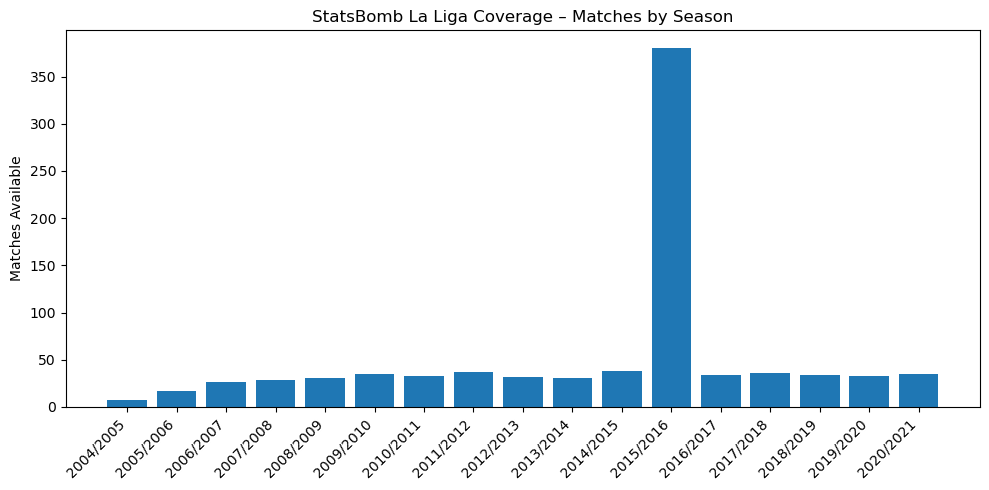

In [5]:
match_counts_df = match_counts_df[
    match_counts_df["season_start"] >= 2004
].sort_values(by="season_start")

plt.figure(figsize=(10, 5))
plt.bar(match_counts_df["season_name"], match_counts_df["matches_count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Matches Available")
plt.title("StatsBomb La Liga Coverage – Matches by Season")
plt.tight_layout()
plt.show()

## 2. Load Competition, Match & Event Data

In [6]:
# Download Matches

leagues = list(zip(
    laliga_comps["competition_id"],
    laliga_comps["season_id"]
))

matches_df = pd.concat([
    sb.matches(competition_id=comp, season_id=season)
    for comp, season in leagues
], ignore_index=True)

len(matches_df)

868

In [7]:
matches_df.head()

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3773386,2020-10-31,21:00:00.000,Spain - La Liga,2020/2021,Deportivo Alavés,Barcelona,1,1,available,available,2023-07-25T03:54:59.280826,2023-07-25T04:25:41.348202,8,Regular Season,Estadio de Mendizorroza,NaN,Pablo Javier Machín Díez,Ronald Koeman,1.1.0,2,2
1,3773565,2021-01-09,18:30:00.000,Spain - La Liga,2020/2021,Granada,Barcelona,0,4,available,available,2023-07-25T03:51:37.437064,2023-07-25T04:30:16.058384,18,Regular Season,Estadio Nuevo Los Cármenes,Ricardo De Burgos Bengoetxea,Diego Martínez Penas,Ronald Koeman,1.1.0,2,2
2,3773457,2021-05-16,18:30:00.000,Spain - La Liga,2020/2021,Barcelona,Celta Vigo,1,2,available,available,2022-12-02T09:26:39.496362,2023-04-27T23:03:53.506485,37,Regular Season,Spotify Camp Nou,NaN,Ronald Koeman,Eduardo Germán Coudet,1.1.0,2,2
3,3773631,2021-02-07,21:00:00.000,Spain - La Liga,2020/2021,Real Betis,Barcelona,2,3,available,available,2023-07-25T03:47:44.278651,2023-07-25T03:56:34.733180,22,Regular Season,Estadio Benito Villamarín,NaN,Manuel Luis Pellegrini Ripamonti,Ronald Koeman,1.1.0,2,2
4,3773665,2021-03-06,21:00:00.000,Spain - La Liga,2020/2021,Osasuna,Barcelona,0,2,available,available,2022-12-02T08:46:42.897589,2023-04-28T02:57:03.412841,26,Regular Season,Estadio El Sadar,Guillermo Cuadra Fernández,Jagoba Arrasate Elustondo,Ronald Koeman,1.1.0,2,2


In [8]:
# Extract Pass Events

CACHE_DIR = Path("statsbomb_cache/events_15_16")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def load_events(match_id):
    cache_file = CACHE_DIR / f"{match_id}.parquet"
    if cache_file.exists():
        return pd.read_parquet(cache_file)

    events = sb.events(match_id=match_id)
    events.to_parquet(cache_file)
    return events

all_passes = []

for match_id in tqdm(matches_df["match_id"], desc="Extracting passes"):
    events = load_events(match_id)
    passes = events[events["type"] == "Pass"].copy()
    passes["match_id"] = match_id
    all_passes.append(passes)

passes_df = pd.concat(all_passes, ignore_index=True)

Extracting passes: 100%|██████████| 868/868 [00:18<00:00, 47.61it/s]


In [9]:
matches_meta = matches_df[[
    "match_id",
    "season",
    "competition",
    "home_team",
    "away_team"
]].copy()

passes_df = passes_df.merge(matches_meta, on="match_id", how="left")

In [10]:
len(passes_df)

880223

In [11]:
passes_df.to_csv("Datasets/passes_laliga_statsbomb_all.csv", index=False)

In [12]:
passes_df = pd.read_csv("Datasets/passes_laliga_statsbomb_all.csv")

C:\Users\vicky\AppData\Local\Temp\ipykernel_27184\953162522.py:1: DtypeWarning: Columns (38,99) have mixed types. Specify dtype option on import or set low_memory=False.
  passes_df = pd.read_csv("Datasets/passes_laliga_statsbomb_all.csv")


## 3. Data Cleaning & Feature Engineering

In [13]:
passes = passes_df.dropna(axis=1, how="all").copy()

# keep only seasons from 2004/2005 onwards
passes = passes[
    passes["season"].str.split("/").str[0].astype(int) >= 2004
].copy()

def extract_coords(col):
    x = pd.to_numeric(col.astype(str).str.strip("[]").str.split().str[0], errors="coerce")
    y = pd.to_numeric(col.astype(str).str.strip("[]").str.split().str[1], errors="coerce")
    return x, y

passes["start_x"], passes["start_y"] = extract_coords(passes["location"])
passes["end_x"], passes["end_y"] = extract_coords(passes["pass_end_location"])

FEATURES = ["start_x", "start_y", "end_x", "end_y"]

# Remove unwanted passes
passes = passes[passes["pass_outcome"] != "Injury Clearance"].copy()

# Drop NaNs in clustering features
passes = passes.dropna(subset=FEATURES).copy()

# Fix pitch bounds

for col, max_val in [("start_x", 120), ("end_x", 120), ("start_y", 80), ("end_y", 80)]:
    passes[col] = passes[col].clip(lower=0, upper=max_val)

In [14]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None )

passes.head()

,counterpress,duration,id,index,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,pass_goal_assist,pass_straight,pass_miscommunication,season,competition,home_team,away_team,start_x,start_y,end_x,end_y
0,NaN,0.963571,208f072d-cffa-4575-bd73-e9e9384c8fe1,5,[61. 40.1],3773386,0,NaN,NaN,NaN,2.692596,NaN,Left Foot,NaN,NaN,NaN,[50. 45.4],Ground Pass,NaN,12.210241,NaN,NaN,NaN,Sergio Busquets i Burgos,5203.0,NaN,NaN,NaN,NaN,Kick Off,1,From Kick Off,Antoine Griezmann,5487.0,Center Forward,2,Barcelona,217,['1b0529a5-c699-44e4-b534-80a48503d3a8'],0,Barcelona,217,00:00:00.689,Pass,NaN,NaN,NaN,NaN,2020/2021,Spain - La Liga,Deportivo Alavés,Barcelona,61.0,40.1,50.0,45.4
1,NaN,0.998827,e1f11e14-fb24-4c82-868f-507385122b9c,7,[49.4 44.9],3773386,0,NaN,NaN,NaN,-1.720006,NaN,Right Foot,NaN,NaN,NaN,[47.1 29.6],Ground Pass,NaN,15.471910,NaN,NaN,NaN,Frenkie de Jong,8118.0,NaN,NaN,NaN,NaN,NaN,1,From Kick Off,Sergio Busquets i Burgos,5203.0,Right Defensive Midfield,2,Barcelona,217,['b9c89821-9722-4c12-ada7-e1d09cc10a89'],1,Barcelona,217,00:00:01.653,Pass,NaN,NaN,NaN,NaN,2020/2021,Spain - La Liga,Deportivo Alavés,Barcelona,49.4,44.9,47.1,29.6
2,NaN,1.263872,4d801bc4-907a-4474-9620-7c6ca2610ea7,10,[48.1 29.6],3773386,0,NaN,NaN,NaN,2.111216,NaN,Right Foot,NaN,NaN,NaN,[35.5 50.6],Ground Pass,NaN,24.489998,NaN,NaN,NaN,Gerard Piqué Bernabéu,5213.0,NaN,NaN,NaN,NaN,NaN,1,From Kick Off,Frenkie de Jong,8118.0,Left Defensive Midfield,2,Barcelona,217,['c4d7296a-bcea-4f7d-bcc9-c1bf5dae6fe7'],5,Barcelona,217,00:00:05.344,Pass,NaN,NaN,NaN,NaN,2020/2021,Spain - La Liga,Deportivo Alavés,Barcelona,48.1,29.6,35.5,50.6
3,NaN,1.331522,72a0c004-6d76-4ea8-b892-0f7881be9320,13,[44.3 50.2],3773386,0,NaN,NaN,NaN,-1.730403,NaN,Right Foot,NaN,NaN,NaN,[41. 29.7],Ground Pass,NaN,20.763910,NaN,NaN,NaN,Clément Lenglet,6826.0,NaN,NaN,NaN,NaN,NaN,1,From Kick Off,Gerard Piqué Bernabéu,5213.0,Right Center Back,2,Barcelona,217,['3d285d86-2ff7-45c9-8447-825fcbe5b5bc'],10,Barcelona,217,00:00:10.283,Pass,NaN,NaN,NaN,NaN,2020/2021,Spain - La Liga,Deportivo Alavés,Barcelona,44.3,50.2,41.0,29.7
4,NaN,1.004666,ba9d104d-bddd-44bd-b156-991e7f5f0344,16,[49. 28.7],3773386,0,NaN,NaN,NaN,0.499347,NaN,Left Foot,NaN,NaN,NaN,[57.8 33.5],Ground Pass,NaN,10.023972,NaN,NaN,NaN,Sergio Busquets i Burgos,5203.0,NaN,NaN,NaN,NaN,NaN,1,From Kick Off,Clément Lenglet,6826.0,Left Center Back,2,Barcelona,217,['ff18cfb6-31ba-4e71-bc9f-5fe07a9d2ceb'],14,Barcelona,217,00:00:14.201,Pass,NaN,NaN,NaN,NaN,2020/2021,Spain - La Liga,Deportivo Alavés,Barcelona,49.0,28.7,57.8,33.5


In [15]:
# BUILD BARÇA BY SEASON (CRITICAL STEP)

barca = passes[passes["team"] == "Barcelona"].copy()
barca["team_season"] = "Barcelona " + barca["season"]

## 4. Clustering Framework (Reusable)

In [16]:
FEATURES = ["start_x", "start_y", "end_x", "end_y"]

def run_clustering(df, n_clusters=50, seed=14):
    scaler = StandardScaler()
    X = scaler.fit_transform(df[FEATURES])

    model = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
    df = df.copy()
    df["cluster"] = model.fit_predict(X)

    return df, scaler, model

## 5. Cluster Analysis Utilities

In [17]:
def compute_zscores(df, cluster_col):

    team_cluster = (
        df.groupby(["team_season", cluster_col])
        .size()
        .reset_index(name="count")
    )

    team_total = df.groupby("team_season").size().reset_index(name="total")

    dist = team_cluster.merge(team_total, on="team_season")
    dist["prop"] = dist["count"] / dist["total"]

    league_avg = dist.groupby(cluster_col)["prop"].mean()
    league_std = dist.groupby(cluster_col)["prop"].std()

    dist["z"] = (
        (dist["prop"] - dist[cluster_col].map(league_avg)) /
        (dist[cluster_col].map(league_std) + 1e-6)
    )

    return dist

## 6. Representative Passes & Descriptions

In [18]:
def representative_passes(df_cluster, scaler, n=30):
    X = scaler.transform(df_cluster[FEATURES])
    centroid = X.mean(axis=0)

    dist = np.linalg.norm(X - centroid, axis=1)
    df_cluster = df_cluster.copy()
    df_cluster["dist"] = dist

    return df_cluster.sort_values("dist").head(n)

## 7. Visualisation Functions

In [19]:
pitch = Pitch(pitch_type="statsbomb", line_color="black")

def plot_team(ax, df, dist, scaler, team_season, cluster_col, display_name=None, top_n=5, show_descriptions=False):

    team_df = df[df["team_season"] == team_season]

    # --- handle z column safely ---
    z_col = "z"

    top_clusters = (
        dist[dist["team_season"] == team_season]
        .sort_values(z_col, ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    cmap = plt.colormaps["tab10"]

    cluster_info = []
    for i, row in enumerate(top_clusters.itertuples()):
        cluster_info.append({
            "cluster": getattr(row, cluster_col),
            "color": cmap(i % 10),
            "idx": i + 1
        })

    # --- DRAW PASSES (UNCHANGED CORE LOGIC) ---
    for info in reversed(cluster_info):
        cluster_df = team_df[team_df[cluster_col] == info["cluster"]]
        reps = representative_passes(cluster_df, scaler)

        for _, p in reps.iterrows():
            ax.arrow(
                p["start_x"], p["start_y"],
                p["end_x"] - p["start_x"],
                p["end_y"] - p["start_y"],
                head_width=1.2,
                head_length=2,
                linewidth=1.3,
                color=info["color"],
                alpha=0.4
            )

    # --- 🔥 RESTORED: LEGEND / REFERENCES ---
    descriptions = [(c["idx"], c["color"]) for c in cluster_info]

    y = -0.02

    if show_descriptions:
        for i, (idx, color) in enumerate(descriptions):
            ax.text(
                0.5,
                y - i * 0.06,
                f"➜ {idx}",
                transform=ax.transAxes,
                fontsize=9,
                color=color,
                ha="center",
                va="top"
            )
    else:
        x_positions = np.linspace(0.2, 0.8, len(descriptions))

        for x, (idx, color) in zip(x_positions, descriptions):
            ax.text(
                x,
                y,
                f"➜ {idx}",
                transform=ax.transAxes,
                fontsize=11,
                color=color,
                ha="center",
                va="top"
            )

    ax.set_title(display_name if display_name else team_season,
                 fontweight="bold", pad=6)

    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])


def plot_grid(df, dist, scaler, cluster_col, title, n_cols=4, show_descriptions=False):

    teams = sorted(df["team_season"].unique())
    n_rows = math.ceil(len(teams) / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(18, 4 * n_rows),
        gridspec_kw={'hspace': 0.08, 'wspace': 0.05}
    )

    axes = np.array(axes).flatten()

    fig.suptitle(title, fontsize=16, fontweight="bold", y=0.92)

    for i, team in enumerate(teams):
        pitch.draw(ax=axes[i])

        plot_team(
            axes[i],
            df,
            dist,
            scaler,
            team,
            cluster_col,
            display_name=f"{i+1}. {team}",
            show_descriptions=show_descriptions
        )

    for j in range(len(teams), len(axes)):
        axes[j].axis("off")

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

## 8. Applications

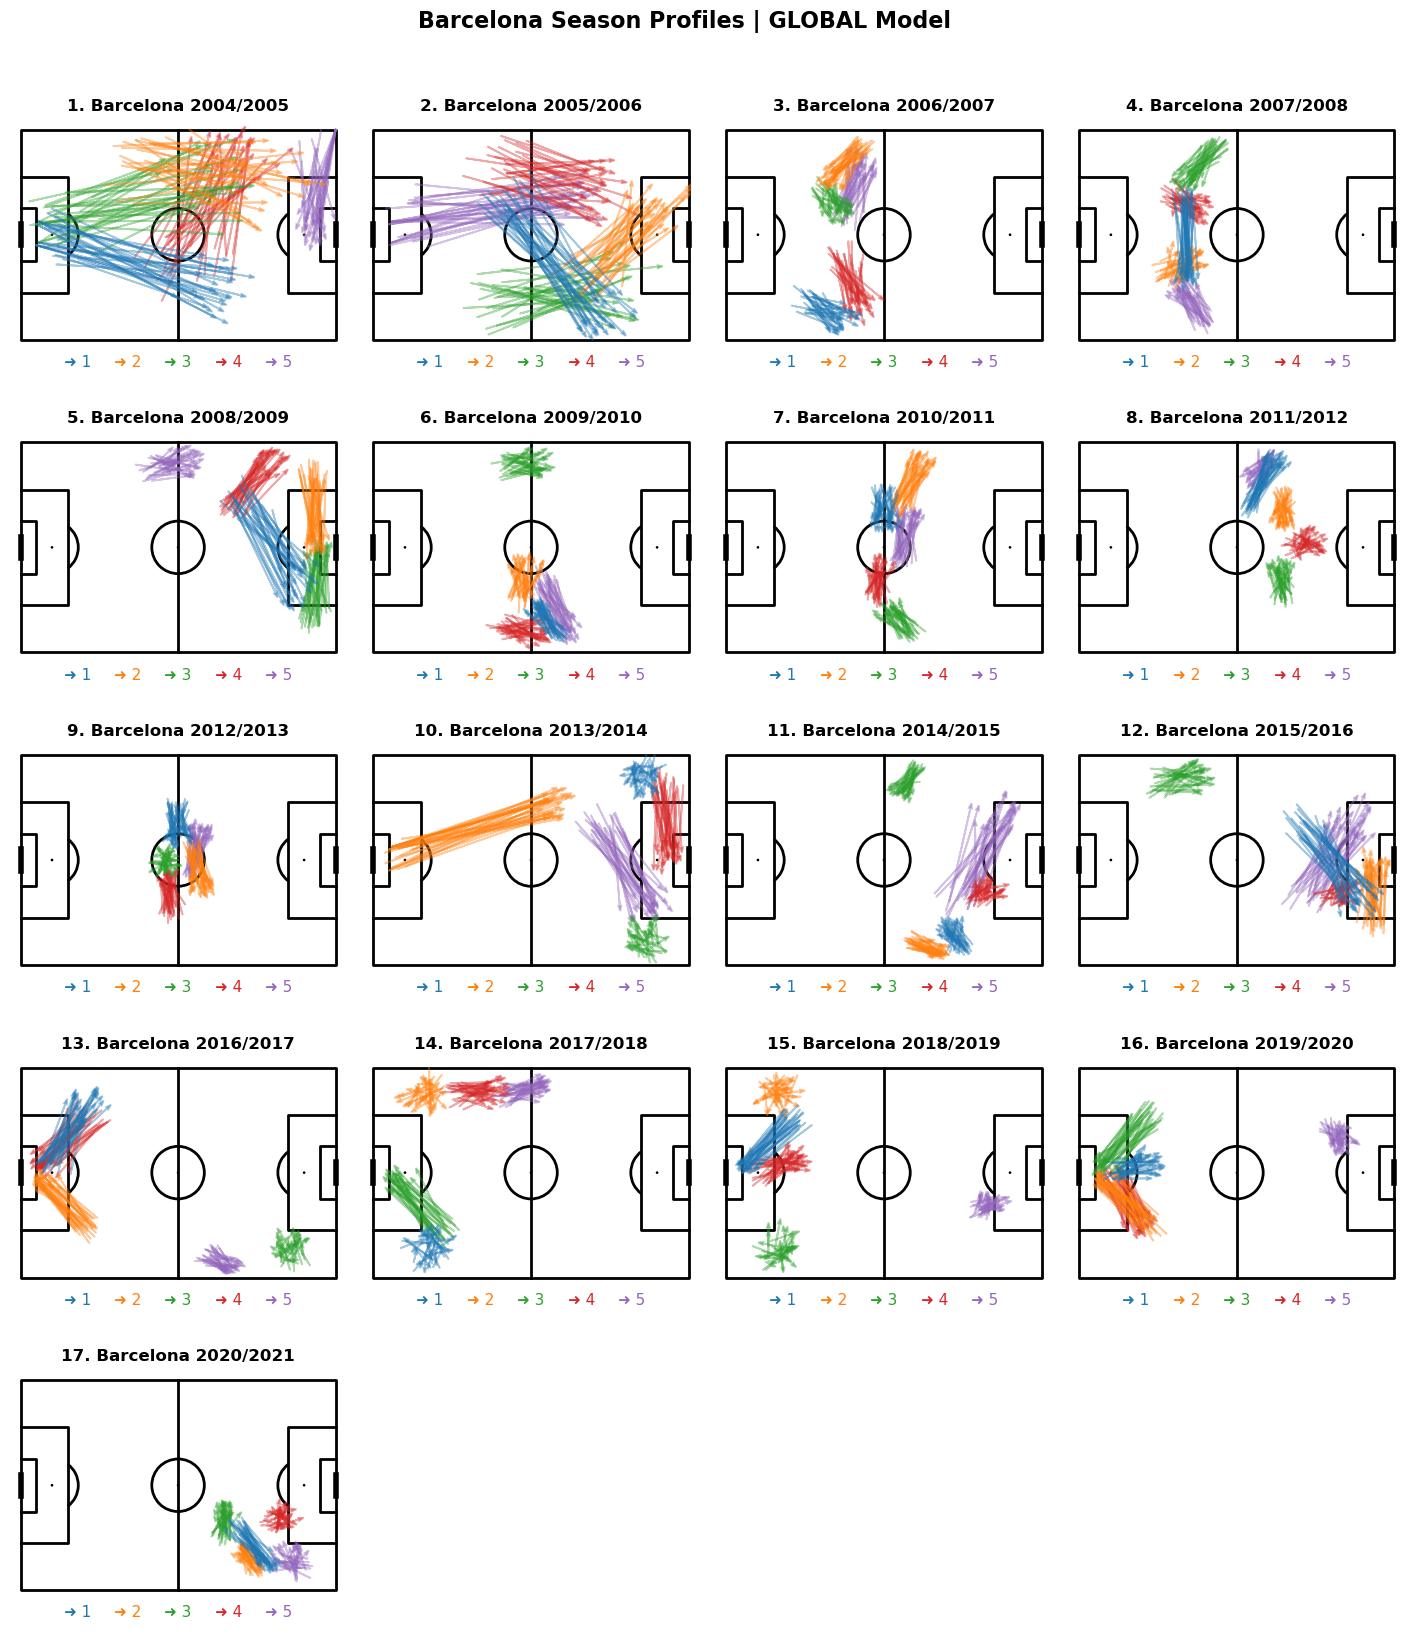

In [20]:
# ALL PASSES

# MODEL 1 — GLOBAL FOOTBALL MODEL

barca = passes[passes["team"] == "Barcelona"].copy()
barca["team_season"] = "Barcelona " + barca["season"]

df_global, scaler_global, kmeans_global = run_clustering(passes)

barca["cluster_global"] = kmeans_global.predict(
    scaler_global.transform(barca[FEATURES])
)

dist_global = compute_zscores(barca, "cluster_global")

plot_grid(
    barca,
    dist_global,
    scaler_global,
    "cluster_global",
    "Barcelona Season Profiles | GLOBAL Model"
)

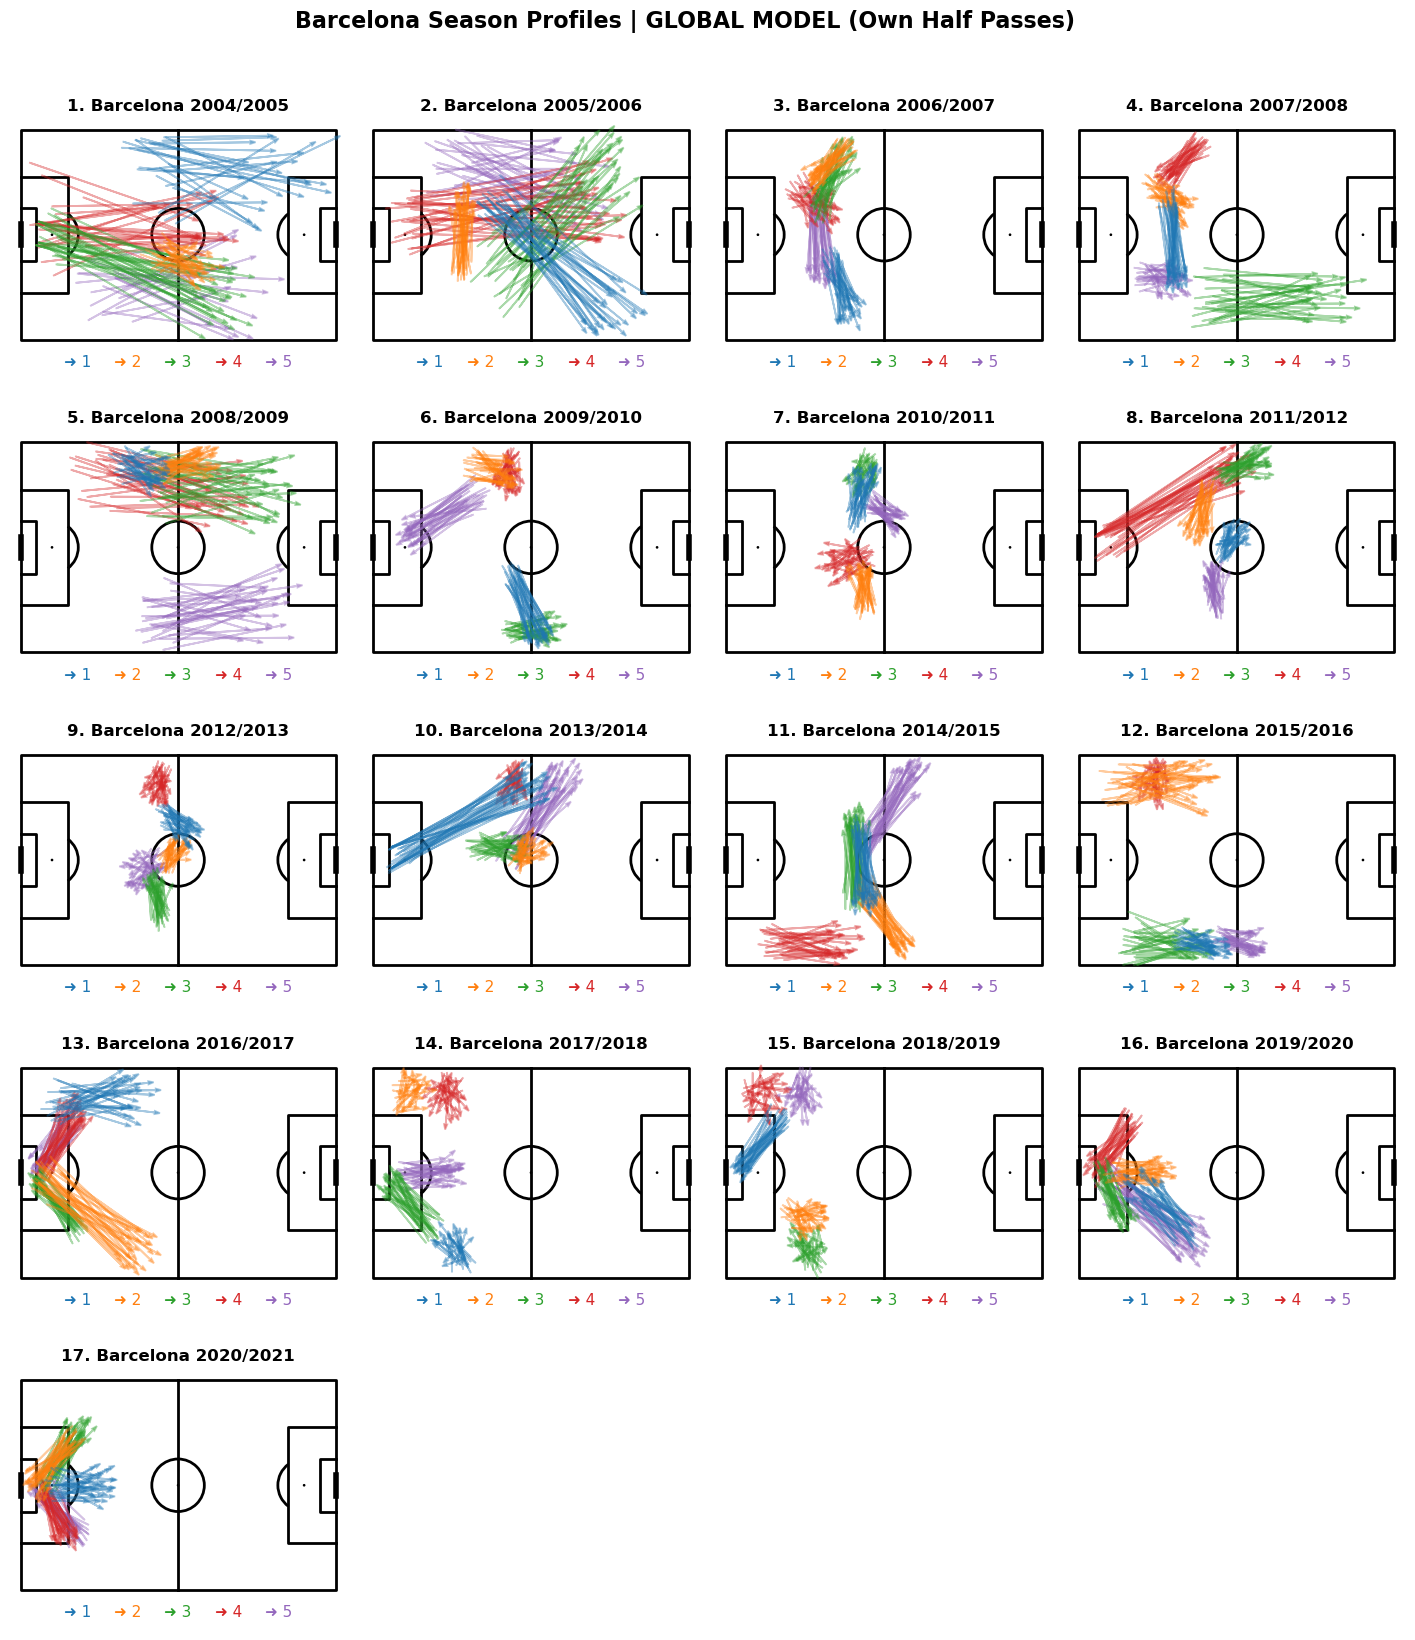

In [21]:
# ============================================================
# FILTER: OWN HALF PASSES (ALL TEAMS for training)
# ============================================================
OWN_HALF_MAX_X = 60

passes_own_half = passes[passes["start_x"] <= OWN_HALF_MAX_X].copy()


# ============================================================
# BARCA FILTER (for application)
# ============================================================
barca_own_half = passes_own_half[passes_own_half["team"] == "Barcelona"].copy()
barca_own_half["team_season"] = "Barcelona " + barca_own_half["season"]


# ============================================================
# MODEL 1 — GLOBAL (OWN HALF CONTEXT)
# ============================================================
df_global_half, scaler_global_half, kmeans_global_half = run_clustering(passes_own_half)

X_barca = scaler_global_half.transform(barca_own_half[FEATURES])

barca_own_half["cluster_global_half"] = kmeans_global_half.predict(X_barca)


# ============================================================
# Z-SCORES
# ============================================================
dist_global_half = compute_zscores(barca_own_half, "cluster_global_half")


# ============================================================
# VISUALISATION
# ============================================================
plot_grid(
    barca_own_half,
    dist_global_half,
    scaler_global_half,
    "cluster_global_half",
    "Barcelona Season Profiles | GLOBAL MODEL (Own Half Passes)"
)

In [ ]:
# MODEL 2 — 2015/16 CONTEXT MODEL

passes_1516 = passes[passes["season"] == "2015/2016"].copy()

df_1516, scaler_1516, kmeans_1516 = run_clustering(passes_1516)

barca_1516 = barca.copy()

barca_1516["cluster_1516"] = kmeans_1516.predict(
    scaler_1516.transform(barca_1516[FEATURES])
)

dist_1516 = compute_zscores(barca_1516, "cluster_1516")


plot_grid(
    barca_1516,
    dist_1516,
    scaler_1516,
    "cluster_1516",
    "Barcelona Season Profiles | 2015/16 Tactical Model"
)

In [ ]:
# ============================================================
# FILTER: OWN HALF (TRAINING DATA - 2015/16 ONLY)
# ============================================================
OWN_HALF_MAX_X = 60

passes_1516_own_half = passes[
    (passes["season"] == "2015/2016") &
    (passes["start_x"] <= OWN_HALF_MAX_X)
].copy()


# ============================================================
# TRAIN MODEL (2015/16 OWN HALF ONLY)
# ============================================================
df_1516_half, scaler_1516_half, kmeans_1516_half = run_clustering(passes_1516_own_half)


# ============================================================
# APPLY TO ALL BARCELONA OWN HALF PASSES
# ============================================================
barca_own_half_1516 = barca_own_half.copy()

barca_own_half_1516["cluster_1516_half"] = kmeans_1516_half.predict(
    scaler_1516_half.transform(barca_own_half_1516[FEATURES])
)


# ============================================================
# Z-SCORES
# ============================================================
dist_1516_half = compute_zscores(barca_own_half_1516, "cluster_1516_half")


# ============================================================
# VISUALISATION
# ============================================================
plot_grid(
    barca_own_half_1516,
    dist_1516_half,
    scaler_1516_half,
    "cluster_1516_half",
    "Barcelona Season Profiles | 2015/16 Tactical Model (Own Half)"
)

fig = plt.gcf()  # 👈 grab current figure

fig.savefig(
    "Images and others/barcelona_2015_16_tactical_model_own_half.png",
    dpi=300,
    bbox_inches="tight"
)

In [ ]:
# MODEL 3 — BARÇA INTERNAL MODEL

# Train ONLY on Barcelona passes (all seasons 2004/05+ already filtered earlier)
df_barca_model, scaler_barca, kmeans_barca = run_clustering(passes)

# Copy Barcelona seasonal structure
barca_barca = barca.copy()

# Apply Barça-trained model to all Barcelona seasons
barca_barca["cluster_barca"] = kmeans_barca.predict(
    scaler_barca.transform(barca_barca[FEATURES])
)

# Compute season-level z-scores (Barcelona seasons vs Barcelona seasons)
dist_barca = compute_zscores(barca_barca, "cluster_barca")

# Plot
plot_grid(
    barca_barca,
    dist_barca,
    scaler_barca,
    "cluster_barca",
    "Barcelona Season Profiles | Barça Internal Passing Model"
)

In [ ]:
# ============================================================
# MODEL 3 — BARÇA INTERNAL MODEL (OWN HALF ONLY)
# ============================================================

# -----------------------------
# 1. FILTER BARÇA + OWN HALF ONLY (TRAINING DATA)
# -----------------------------
passes_barca_ownhalf = passes[
    (passes["team"] == "Barcelona") &
    (passes["start_x"] <= 60)
].copy()

passes_barca_ownhalf["team_season"] = (
    "Barcelona " + passes_barca_ownhalf["season"]
)

# -----------------------------
# 2. TRAIN MODEL ONLY ON BARÇA OWN HALF PASSES
# -----------------------------
df_barca_model, scaler_barca, kmeans_barca = run_clustering(
    passes_barca_ownhalf
)

# -----------------------------
# 3. APPLY MODEL TO ALL BARÇA SEASONS (OWN HALF ONLY)
# -----------------------------
barca_barca = barca.copy()
barca_barca = barca_barca[barca_barca["start_x"] <= 60].copy()

barca_barca["cluster_barca_ownhalf"] = kmeans_barca.predict(
    scaler_barca.transform(barca_barca[FEATURES])
)

# -----------------------------
# 4. Z-SCORES (BARÇA ONLY COMPARISON SPACE)
# -----------------------------
dist_barca = compute_zscores(barca_barca, "cluster_barca_ownhalf")

# -----------------------------
# 5. PLOT
# -----------------------------
plot_grid(
    barca_barca,
    dist_barca,
    scaler_barca,
    "cluster_barca_ownhalf",
    "Barcelona Season Profiles | Barça Internal Model (Own Half)"
)

# STATS

In [ ]:
import numpy as np
import pandas as pd

def time_to_seconds(t):
    """Convert HH:MM:SS.ms → seconds safely"""
    if pd.isna(t):
        return np.nan
    h, m, s = str(t).split(":")
    return int(h)*3600 + int(m)*60 + float(s)

In [ ]:
import numpy as np
import pandas as pd

OWN_THIRD_MAX_X = 40


# ============================================================
# TIME CONVERSION
# ============================================================
def time_to_seconds(t):
    """Convert HH:MM:SS.ms → seconds"""
    h, m, s = t.split(":")
    return int(h) * 3600 + int(m) * 60 + float(s)


# ============================================================
# MAIN FUNCTION
# ============================================================
def compute_buildup_metrics_team_season(df, team_name="Barcelona"):

    df = df.copy()

    # ============================================================
    # KEEP PASSES ONLY
    # ============================================================
    df_passes = df[df["type"] == "Pass"].copy()

    # ============================================================
    # POSSESSION (CORRECT: TEAM vs ALL TEAMS, PER SEASON)
    # ============================================================
    team_match_passes = (
        df_passes.groupby(["match_id", "season", "team"])
        .size()
        .reset_index(name="team_passes")
    )

    match_total_passes = (
        df_passes.groupby(["match_id", "season"])
        .size()
        .reset_index(name="match_passes")
    )

    possession_df = team_match_passes.merge(
        match_total_passes,
        on=["match_id", "season"],
        how="left"
    )

    possession_df["possession"] = (
        possession_df["team_passes"] / possession_df["match_passes"]
    )

    # KEEP ONLY BARCELONA FOR FINAL MERGE (BUT AFTER CORRECT CALC)
    team_possession = (
        possession_df[possession_df["team"] == team_name]
        .groupby(["team", "season"])
        .agg(possession=("possession", "mean"))
        .reset_index()
    )

    # ============================================================
    # FILTER BARCELONA ONLY FOR BUILDUPS
    # ============================================================
    df = df_passes[df_passes["team"] == team_name].copy()

    df["time_sec"] = df["timestamp"].apply(time_to_seconds)
    df = df.sort_values(["match_id", "period", "possession", "index"])

    buildups = []

    # ============================================================
    # BUILDUP EXTRACTION
    # ============================================================
    for (match_id, period, possession), group in df.groupby(
        ["match_id", "period", "possession"]
    ):

        group = group.sort_values("index")
        first = group.iloc[0]

        if first["start_x"] > OWN_THIRD_MAX_X:
            continue

        is_gk = first.get("position") == "Goalkeeper"
        is_regain = first.get("regain", 0) == 1

        if not (is_gk or is_regain):
            continue

        buildup_passes = []

        for _, row in group.iterrows():
            if row["start_x"] > OWN_THIRD_MAX_X:
                break
            buildup_passes.append(row)

        if len(buildup_passes) < 2:
            continue

        bdf = pd.DataFrame(buildup_passes)

        n_passes = len(bdf)

        duration = (
            bdf["time_sec"].iloc[-1] - bdf["time_sec"].iloc[0]
        )

        is_direct = (bdf.get("pass_length", 0) > 25).any()

        buildups.append({
            "team": team_name,
            "season": first["season"],
            "team_season": f"{team_name} {first['season']}",
            "match_id": match_id,
            "n_passes": n_passes,
            "duration_sec": duration,
            "is_direct": int(is_direct)
        })

    buildup_df = pd.DataFrame(buildups)

    # ============================================================
    # AGGREGATION (TEAM + SEASON)
    # ============================================================
    team_stats = buildup_df.groupby(["team", "season", "team_season"]).agg(
        matches=("match_id", "nunique"),  # ✅ NEW
        buildups=("n_passes", "count"),
        avg_passes=("n_passes", "mean"),
        avg_duration_sec=("duration_sec", "mean"),
        direct_buildups=("is_direct", "sum")
            ).reset_index()
    
    team_stats["directness_pct"] = (
        team_stats["direct_buildups"] / team_stats["buildups"]
    )

    # ============================================================
    # MERGE CORRECT SEASON POSSESSION
    # ============================================================
    team_stats = team_stats.merge(
        team_possession,
        on=["team", "season"],
        how="left"
    )

    return team_stats, buildup_df

In [ ]:
team_stats_ts, buildup_ts = compute_buildup_metrics_team_season(passes)

team_stats_ts.sort_values(["team", "season"])

# Passing Networks

In [ ]:
import pandas as pd
from collections import Counter
from statsbombpy import sb

# ------------------------------------------------------------
# LOAD MATCHES
# ------------------------------------------------------------
competitions = sb.competitions()

laliga = competitions[
    (competitions["competition_name"] == "La Liga") &
    (competitions["competition_gender"] == "male")
]

leagues = list(zip(laliga["competition_id"], laliga["season_id"]))

matches = pd.concat(
    [sb.matches(comp, season) for comp, season in leagues],
    ignore_index=True
)

barca_matches = matches[
    (matches["home_team"] == "Barcelona") |
    (matches["away_team"] == "Barcelona")
].copy()


# ------------------------------------------------------------
# STARTING XI FUNCTION
# ------------------------------------------------------------
def get_starting_xi(match_id: int, team: str):

    lineup = sb.lineups(match_id=match_id)[team].copy()

    df = lineup.explode("positions")
    pos = pd.json_normalize(df["positions"])

    df = pd.concat(
        [df.drop(columns="positions").reset_index(drop=True), pos],
        axis=1
    )

    starters = df[df["start_reason"] == "Starting XI"].copy()

    starters["player_full"] = starters["player_name"].str.strip()

    starters["player"] = (
        starters["player_nickname"]
        .fillna(starters["player_name"])
        .str.strip()
    )

    return starters[["player", "player_full", "position"]]

In [ ]:
def build_player_position_counts(matches_df):

    rows = []

    seasons = matches_df["season"].unique()

    for season in seasons:

        print(f"\n📅 Processing {season}")

        season_matches = matches_df[
            matches_df["season"] == season
        ]

        player_position_counts = Counter()
        player_full_map = {}

        for match_id in season_matches["match_id"]:

            try:
                xi = get_starting_xi(match_id, "Barcelona")

                for _, row in xi.iterrows():

                    key = (row["player"], row["position"])
                    player_position_counts[key] += 1

                    player_full_map[row["player"]] = row["player_full"]

            except:
                continue

        # convert to dataframe
        for (player, pos), count in player_position_counts.items():

            rows.append({
                "season": season,
                "player": player,
                "player_full": player_full_map[player],
                "position": pos,
                "appearances": count
            })

    return pd.DataFrame(rows)

In [ ]:
player_position_df = pd.read_csv("barca_player_position_counts.csv")

In [ ]:
from collections import defaultdict
import pandas as pd


def get_barca_xi_by_season(player_position_df):

    results = []

    for season in player_position_df["season"].unique():

        print(f"\n➡️ Season {season}")

        df = player_position_df[
            player_position_df["season"] == season
        ].copy()

        # ----------------------------------------
        # POSITION IMPORTANCE
        # ----------------------------------------
        position_freq = (
            df.groupby("position")["appearances"]
            .sum()
            .to_dict()
        )

        max_freq = max(position_freq.values())

        df["position_weight"] = df["position"].map(position_freq) / max_freq
        df["base_score"] = df["appearances"] * df["position_weight"]

        df = df.sort_values("base_score", ascending=False)

        # ----------------------------------------
        # HARD CONSTRAINT SELECTION
        # ----------------------------------------
        selected_players = set()
        position_counts = defaultdict(int)

        xi_rows = []

        for _ in range(11):

            best_idx = None
            best_score = -1

            for idx, row in df.iterrows():

                # ❌ already selected player
                if row["player"] in selected_players:
                    continue

                # ❌ FORBID duplicate positions
                if position_counts[row["position"]] >= 1:
                    continue

                score = row["base_score"]

                if score > best_score:
                    best_score = score
                    best_idx = idx

            if best_idx is None:
                break

            chosen = df.loc[best_idx]

            xi_rows.append(chosen)
            selected_players.add(chosen["player"])
            position_counts[chosen["position"]] += 1

        xi_df = pd.DataFrame(xi_rows)

        print(f"   ✅ XI selected ({len(xi_df)} players)")

        results.append(xi_df)

    return pd.concat(results, ignore_index=True)

In [ ]:
barca_xi_by_season = get_barca_xi_by_season(player_position_df)

In [ ]:
barca_xi_by_season

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch


# ============================================================
# 1. ORIGINAL FUNCTION (UNCHANGED)
# ============================================================
def plot_barca_season_network(passes, season, barca_xi_by_season):

    season_clean = str(season).replace("/", "–")

    title = f"FC Barcelona Passing Network — {season_clean}"

    subtitle = (
        "Starting XI passing structure reconstructed from StatsBomb event data\n"
        "Nodes represent positional role clustering; edges represent successful passes"
    )

    df_season = passes[
        (passes["team"] == "Barcelona") &
        (passes["season"] == season)
    ].copy()

    if df_season.empty:
        return

    df_season = df_season[df_season["pass_outcome"].isna()].copy()

    xi_df = barca_xi_by_season[
        barca_xi_by_season["season"] == season
    ].copy()

    xi_df = xi_df.sort_values("appearances", ascending=False)
    xi_df = xi_df.drop_duplicates(subset="player_full").head(11)

    starting_full = xi_df["player_full"].tolist()
    name_map = dict(zip(xi_df["player_full"], xi_df["player"]))

    df = df_season[
        df_season["player"].isin(starting_full) |
        df_season["pass_recipient"].isin(starting_full)
    ].copy()

    if df.empty:
        return

    start = df[["player", "start_x", "start_y"]].rename(
        columns={"start_x": "x", "start_y": "y"}
    )

    end = df[["pass_recipient", "end_x", "end_y"]].rename(
        columns={"pass_recipient": "player", "end_x": "x", "end_y": "y"}
    )

    locs = pd.concat([start, end])

    avg = (
        locs.groupby("player")
        .agg(x=("x", "mean"), y=("y", "mean"), touches=("x", "count"))
        .reset_index()
    )

    avg = avg.dropna(subset=["x", "y"])

    def position_order(pos):
        pos = str(pos).lower()

        if "goalkeeper" in pos:
            return 0
        if "left back" in pos:
            return 1
        if "left center back" in pos:
            return 2
        if "right center back" in pos:
            return 3
        if "right back" in pos:
            return 4
        if "defensive midfield" in pos:
            return 5
        if "center midfield" in pos:
            return 6
        if "left midfield" in pos or "left wing" in pos:
            return 7
        if "right midfield" in pos or "right wing" in pos:
            return 8
        if "forward" in pos or "striker" in pos:
            return 9

        return 10

    xi_df = barca_xi_by_season[
        barca_xi_by_season["season"] == season
    ].copy()

    xi_df = xi_df.drop_duplicates(subset="player_full")
    xi_df["order"] = xi_df["position"].apply(position_order)
    xi_df = xi_df.sort_values(["order", "appearances"], ascending=[True, False])
    xi_df = xi_df.head(11)

    xi_display = xi_df.copy()

    xi_positions = avg[avg["player"].isin(starting_full)].copy()
    xi_positions = xi_positions.rename(columns={"player": "node"})

    player_map = {}

    for _, row in avg.iterrows():
        dx = xi_positions["x"].values - row["x"]
        dy = xi_positions["y"].values - row["y"]
        dists = np.sqrt(dx**2 + dy**2)

        closest = xi_positions.iloc[np.argmin(dists)]["node"]
        player_map[row["player"]] = closest

    df["node_from"] = df["player"].map(player_map)
    df["node_to"] = df["pass_recipient"].map(player_map)

    node_pos = (
        avg.groupby(avg["player"].map(player_map))
        .agg(x=("x", "mean"), y=("y", "mean"))
        .reset_index()
        .rename(columns={"player": "node"})
    ).head(11)

    links = (
        df.groupby(["node_from", "node_to"])
        .size()
        .reset_index(name="count")
    )

    links = links[links["node_from"] != links["node_to"]]

    links = links.merge(node_pos, left_on="node_from", right_on="node")
    links = links.merge(
        node_pos,
        left_on="node_to",
        right_on="node",
        suffixes=("_start", "_end")
    )

    max_count = links["count"].max()
    links["width"] = (links["count"] / max_count) * 10
    links["alpha"] = 0.3 + (links["count"] / max_count) * 0.7

    pitch = Pitch(pitch_type="statsbomb", line_color="black")
    fig, ax = pitch.draw(figsize=(14, 7))

    fig.set_facecolor("white")
    ax.set_facecolor("white")

    for _, r in links.iterrows():
        pitch.lines(
            r.x_start, r.y_start,
            r.x_end, r.y_end,
            lw=r.width,
            color="red",
            alpha=r.alpha,
            ax=ax,
            zorder=1
        )

    pitch.scatter(
        node_pos.x,
        node_pos.y,
        s=500,
        color="blue",
        edgecolor="black",
        linewidth=1.5,
        ax=ax,
        zorder=3
    )

    for _, r in node_pos.iterrows():
        label = name_map.get(r["node"], r["node"])

        ax.text(
            r.x,
            r.y,
            label,
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            bbox=dict(
                facecolor="white",
                alpha=0.6,
                edgecolor="none",
                boxstyle="round,pad=0.2"
            ),
            zorder=4
        )

    plt.suptitle(title, fontsize=16, fontweight="bold", y=0.975)
    plt.title(subtitle, fontsize=10, style="italic", color="gray", y=0.96)

    xi_text = "\n".join([
        f"{row['player']} ({row['position']}) – {row['appearances']}"
        for _, row in xi_display.iterrows()
    ])

    plt.subplots_adjust(right=0.65)

    fig.text(0.9, 0.5, xi_text, fontsize=10, va="center")

    fig.text(
        0.8, 0.09,
        "Victoria Friss de Kereki",
        ha="right",
        fontsize=11,
        color="#888888",
        transform=fig.transFigure
    )

    fig.text(
        0.8, 0.07,
        "Sports Analytics & Data Science",
        ha="right",
        fontsize=9.5,
        color="#aaaaaa",
        transform=fig.transFigure
    )

    plt.show()


# ============================================================
# 2. GRID VERSION (SMALL, NO XI)
# ============================================================
def plot_barca_season_network_grid(passes, season, barca_xi_by_season, ax):

    season_clean = str(season).replace("/", "–")

    df_season = passes[
        (passes["team"] == "Barcelona") &
        (passes["season"] == season)
    ].copy()

    if df_season.empty:
        ax.axis("off")
        return

    df_season = df_season[df_season["pass_outcome"].isna()].copy()

    xi_df = barca_xi_by_season[
        barca_xi_by_season["season"] == season
    ].copy()

    xi_df = xi_df.sort_values("appearances", ascending=False)
    xi_df = xi_df.drop_duplicates(subset="player_full").head(11)

    starting_full = xi_df["player_full"].tolist()
    name_map = dict(zip(xi_df["player_full"], xi_df["player"]))

    df = df_season[
        df_season["player"].isin(starting_full) |
        df_season["pass_recipient"].isin(starting_full)
    ].copy()

    if df.empty:
        ax.axis("off")
        return

    # ------------------------------------------------------------
    # POSITION AVERAGING (unchanged logic)
    # ------------------------------------------------------------
    start = df[["player", "start_x", "start_y"]].rename(columns={"start_x": "x", "start_y": "y"})
    end = df[["pass_recipient", "end_x", "end_y"]].rename(columns={"pass_recipient": "player", "end_x": "x", "end_y": "y"})

    locs = pd.concat([start, end])

    avg = (
        locs.groupby("player")
        .agg(x=("x", "mean"), y=("y", "mean"))
        .reset_index()
        .dropna()
    )

    xi_positions = avg[avg["player"].isin(starting_full)].copy()
    xi_positions = xi_positions.rename(columns={"player": "node"})

    player_map = {}
    for _, row in avg.iterrows():
        dx = xi_positions["x"].values - row["x"]
        dy = xi_positions["y"].values - row["y"]
        dists = np.sqrt(dx**2 + dy**2)
        player_map[row["player"]] = xi_positions.iloc[np.argmin(dists)]["node"]

    df["node_from"] = df["player"].map(player_map)
    df["node_to"] = df["pass_recipient"].map(player_map)

    node_pos = (
        avg.groupby(avg["player"].map(player_map))
        .agg(x=("x", "mean"), y=("y", "mean"))
        .reset_index()
        .rename(columns={"player": "node"})
    )

    links = (
        df.groupby(["node_from", "node_to"])
        .size()
        .reset_index(name="count")
    )

    links = links[links["node_from"] != links["node_to"]]

    links = links.merge(node_pos, left_on="node_from", right_on="node")
    links = links.merge(node_pos, left_on="node_to", right_on="node", suffixes=("_start", "_end"))

    max_count = links["count"].max()

    links["width"] = (links["count"] / max_count) * 6
    links["alpha"] = 0.3 + (links["count"] / max_count) * 0.6

    # ------------------------------------------------------------
    # PITCH (FULL MPLSOCCER CONTROL)
    # ------------------------------------------------------------
    pitch = Pitch(
        pitch_type="statsbomb",
        line_color="black",
        linewidth=2
    )

    pitch.draw(ax=ax)

    # edges
    for _, r in links.iterrows():
        pitch.lines(
            r.x_start, r.y_start,
            r.x_end, r.y_end,
            lw=r.width,
            color="red",
            alpha=r.alpha,
            ax=ax,
            zorder=1
        )

    # nodes
    pitch.scatter(
        node_pos.x,
        node_pos.y,
        s=240,
        color="blue",
        edgecolor="black",
        linewidth=1.2,
        ax=ax,
        zorder=3
    )

    # labels
    for _, r in node_pos.iterrows():
        label = name_map.get(r["node"], r["node"])

        ax.text(
            r.x,
            r.y,
            label,
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold",
            bbox=dict(
                facecolor="white",
                alpha=0.6,
                edgecolor="none",
                boxstyle="round,pad=0.2"
            ),
            zorder=4
        )

    ax.set_title(season_clean, fontsize=11, fontweight="bold", pad=2)


# ============================================================
# 3. GRID RUNNER (CLEAN MPLSOCCER BEHAVIOUR)
# ============================================================
def plot_all_seasons_grid(passes, barca_xi_by_season, n_cols=4, save_path=None):

    seasons = sorted(passes["season"].unique())
    n_rows = int(np.ceil(len(seasons) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 4 * n_rows)
    )

    axes = axes.flatten()

    for i, season in enumerate(seasons):
        plot_barca_season_network_grid(
            passes,
            season,
            barca_xi_by_season,
            axes[i]
        )

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        "FC Barcelona Passing Networks by Season",
        fontsize=18,
        fontweight="bold",
        y=0.97
    )

    plt.subplots_adjust(
        left=0.03,
        right=0.97,
        top=0.93,
        bottom=0.03,
        wspace=0.02,
        hspace=0.1
    )

    if save_path is not None:
        import os
        os.makedirs(os.path.dirname(save_path), exist_ok=True)

        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

In [ ]:
# ORIGINAL (same as before)
for season in sorted(passes["season"].unique()):
    plot_barca_season_network(passes, season, barca_xi_by_season)

In [ ]:
plot_all_seasons_grid(
    passes,
    barca_xi_by_season,
    n_cols=3,
    save_path="Images and others/barca_network_grid.png"
)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from scipy.optimize import linear_sum_assignment

# ============================================================
# 1. HELPERS
# ============================================================
def norm(x):
    if pd.isna(x):
        return None
    return str(x).strip().lower()


def to_min(t):
    if pd.isna(t) or t is None:
        return None
    if isinstance(t, (int, float)):
        return None
    if ":" not in str(t):
        return None

    m, s = str(t).split(":")
    return int(m) + int(s) / 60


# ============================================================
# 2. STARTING XI (MODEL + DISPLAY KEPT SEPARATE)
# ============================================================
def get_starting_xi(match_id, team, sb):

    try:
        lineup = sb.lineups(match_id=match_id)[team]
    except Exception:
        return None

    df = lineup.explode("positions")
    pos = pd.json_normalize(df["positions"])

    df = pd.concat(
        [df.drop(columns="positions").reset_index(drop=True), pos],
        axis=1
    )

    # MODEL KEY
    df["player"] = df["player_name"].apply(norm)

    # DISPLAY ONLY (not used in modelling)
    df["nickname"] = df["player_nickname"]

    df["start"] = df["from"].apply(to_min)
    df["end"] = df["to"].apply(to_min)

    df["start"] = df["start"].fillna(0)
    df["end"] = df["end"].fillna(90)

    starters = df[df["start"] == 0].copy()

    if len(starters) < 11:
        return None

    return starters.head(11)[["player", "nickname", "start", "end"]]


# ============================================================
# 3. MATCH NETWORK (NO NICKNAMES HERE)
# ============================================================
def build_match_network(match_id, team, passes, sb):

    df = passes[passes["match_id"] == match_id].copy()

    if "team" in df.columns:
        df = df[df["team"] == team]

    if df.empty:
        return None

    # MODEL KEYS ONLY
    df["p"] = df["player"].apply(norm)
    df["r"] = df["pass_recipient"].apply(norm)

    xi = get_starting_xi(match_id, team, sb)

    if xi is None:
        return None

    starters = xi["player"].tolist()

    df = df[df["p"].isin(starters) & df["r"].isin(starters)]

    if df.empty:
        return None

    # -------------------------
    # POSITIONS (MODEL ONLY)
    # -------------------------
    start = df[["p", "start_x", "start_y"]].rename(
        columns={"p": "player", "start_x": "x", "start_y": "y"}
    )

    end = df[["r", "end_x", "end_y"]].rename(
        columns={"r": "player", "end_x": "x", "end_y": "y"}
    )

    locs = pd.concat([start, end])

    avg = (
        locs.groupby("player")
        .agg(x=("x", "mean"), y=("y", "mean"))
        .reset_index()
    )

    avg = avg[avg["player"].isin(starters)]

    if len(avg) < 11:
        return None

    # -------------------------
    # SHARED MINUTES
    # -------------------------
    minutes = {
        row["player"]: (row["start"], row["end"])
        for _, row in xi.iterrows()
    }

    pairs = df.groupby(["p", "r"]).size().reset_index(name="count")

    edges = []

    for _, r in pairs.iterrows():

        p1, p2 = r["p"], r["r"]

        if p1 not in minutes or p2 not in minutes:
            continue

        s1, e1 = minutes[p1]
        s2, e2 = minutes[p2]

        overlap = max(0, min(e1, e2) - max(s1, s2))

        if overlap <= 0:
            continue

        weight = r["count"] / overlap * 90

        edges.append({
            "from": p1,
            "to": p2,
            "weight": weight
        })

    edges = pd.DataFrame(edges)

    if edges.empty:
        return None

    return avg, edges


# ============================================================
# 4. SEASON NETWORK (LABELS ONLY AT THE END)
# ============================================================
def build_season_network(passes, sb, team, season):

    df = passes[
        (passes["team"] == team) &
        (passes["season"] == season)
    ]

    match_ids = df["match_id"].dropna().unique()

    match_nodes = []
    match_edges = []

    xi_lookup = []

    for m in match_ids:

        xi = get_starting_xi(m, team, sb)
        if xi is None:
            continue

        xi_lookup.append(xi)

        res = build_match_network(m, team, passes, sb)

        if res is None:
            continue

        nodes, edges = res

        match_nodes.append(nodes)
        match_edges.append(edges)

    if len(match_nodes) == 0:
        raise ValueError("No valid matches found")

    xi_lookup = pd.concat(xi_lookup, ignore_index=True)[["player", "nickname"]].drop_duplicates()

    # -------------------------
    # ALIGN MATCHES
    # -------------------------
    reference = match_nodes[0].copy()
    reference["slot"] = range(11)

    aligned_nodes = []

    for nodes in match_nodes:

        cost = np.linalg.norm(
            nodes[["x", "y"]].values[:, None, :] -
            reference[["x", "y"]].values[None, :, :],
            axis=2
        )

        row_ind, col_ind = linear_sum_assignment(cost)

        nodes = nodes.iloc[row_ind].copy()
        nodes["slot"] = col_ind

        aligned_nodes.append(nodes)

    nodes_df = pd.concat(aligned_nodes, ignore_index=True)
    edges_df = pd.concat(match_edges, ignore_index=True)

    # -------------------------
    # NODE POSITIONS
    # -------------------------
    node_pos = (
        nodes_df.groupby("slot")
        .agg(x=("x", "mean"), y=("y", "mean"))
        .reset_index()
    )

    # most frequent player per slot
    node_labels = (
        nodes_df.groupby(["slot", "player"])
        .size()
        .reset_index(name="count")
        .sort_values(["slot", "count"], ascending=[True, False])
        .drop_duplicates("slot")
    )

    node_pos = node_pos.merge(node_labels[["slot", "player"]], on="slot")

    # -------------------------
    # DISPLAY LAYER ONLY
    # -------------------------
    node_pos = node_pos.merge(xi_lookup, on="player", how="left")
    node_pos["label"] = node_pos["nickname"].fillna(node_pos["player"])

    # -------------------------
    # EDGES
    # -------------------------
    edges_df = (
        edges_df.groupby(["from", "to"])["weight"]
        .mean()
        .reset_index()
    )

    player_to_slot = nodes_df.groupby("player")["slot"].agg(lambda x: x.mode()[0])

    edges_df["slot_from"] = edges_df["from"].map(player_to_slot)
    edges_df["slot_to"] = edges_df["to"].map(player_to_slot)

    edges_df = edges_df.merge(node_pos, left_on="slot_from", right_on="slot")
    edges_df = edges_df.merge(
        node_pos,
        left_on="slot_to",
        right_on="slot",
        suffixes=("_start", "_end")
    )

    return node_pos, edges_df


# ============================================================
# 5. PLOT
# ============================================================
def plot_season_network(node_pos, links, title, subtitle):

    pitch = Pitch(pitch_type="statsbomb", line_color="black")
    fig, ax = pitch.draw(figsize=(14, 7))

    fig.set_facecolor("white")
    ax.set_facecolor("white")

    max_w = links["weight"].max()

    links["width"] = (links["weight"] / max_w) * 10
    links["alpha"] = 0.3 + (links["weight"] / max_w) * 0.7

    for _, r in links.iterrows():
        pitch.lines(
            r.x_start, r.y_start,
            r.x_end, r.y_end,
            lw=r.width,
            color="red",
            alpha=r.alpha,
            ax=ax,
            zorder=1
        )

    pitch.scatter(
        node_pos.x,
        node_pos.y,
        s=500,
        color="blue",
        edgecolor="black",
        linewidth=1.5,
        ax=ax,
        zorder=3
    )

    for _, r in node_pos.iterrows():
        ax.text(
            r.x,
            r.y,
            r["label"],
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            bbox=dict(
                facecolor="white",
                alpha=0.6,
                edgecolor="none",
                boxstyle="round,pad=0.2"
            ),
            zorder=4
        )

    plt.suptitle(title, fontsize=16, fontweight="bold", y=0.975)
    plt.title(subtitle, fontsize=10, style="italic", color="gray", y=0.96)

    plt.show()


# ============================================================
# 6. RUN
# ============================================================
node_pos, links = build_season_network(
    passes,
    sb,
    team="Barcelona",
    season="2015/2016"
)

plot_season_network(
    node_pos,
    links,
    title="FC Barcelona Passing Network — 2015–2016",
    subtitle="StatsBomb-native structure (player_name model + nickname display layer)"
)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from scipy.optimize import linear_sum_assignment


# ============================================================
# 1. HELPERS
# ============================================================
def norm(x):
    if pd.isna(x):
        return None
    return str(x).strip().lower()


def to_min(t):
    if pd.isna(t) or t is None:
        return None
    if isinstance(t, (int, float)):
        return None
    if ":" not in str(t):
        return None
    m, s = str(t).split(":")
    return int(m) + int(s) / 60


# ============================================================
# 2. STARTING XI
# ============================================================
def get_starting_xi(match_id, team, sb):

    try:
        lineup = sb.lineups(match_id=match_id)[team]
    except Exception:
        return None

    df = lineup.explode("positions")
    pos = pd.json_normalize(df["positions"])
    df = pd.concat([df.drop(columns="positions").reset_index(drop=True), pos], axis=1)

    df["player"] = df["player_name"].apply(norm)
    df["nickname"] = df["player_nickname"]

    df["start"] = df["from"].apply(to_min).fillna(0)
    df["end"] = df["to"].apply(to_min).fillna(90)

    starters = df[df["start"] == 0].copy()

    if len(starters) < 11:
        return None

    return starters.head(11)[["player", "nickname", "start", "end"]]


# ============================================================
# 3. MATCH NETWORK (ONE TEAM)
# ============================================================
def build_match_network(match_id, team, passes, sb):

    df = passes[(passes["match_id"] == match_id) & (passes["team"] == team)].copy()
    if df.empty:
        return None

    df["p"] = df["player"].apply(norm)
    df["r"] = df["pass_recipient"].apply(norm)

    xi = get_starting_xi(match_id, team, sb)
    if xi is None:
        return None

    starters = xi["player"].tolist()
    df = df[df["p"].isin(starters) & df["r"].isin(starters)]

    if df.empty:
        return None

    start = df[["p", "start_x", "start_y"]].rename(columns={"p": "player", "start_x": "x", "start_y": "y"})
    end = df[["r", "end_x", "end_y"]].rename(columns={"r": "player", "end_x": "x", "end_y": "y"})
    locs = pd.concat([start, end])

    avg = locs.groupby("player").agg(x=("x", "mean"), y=("y", "mean")).reset_index()

    if len(avg) < 5:
        return None

    minutes = {row["player"]: (row["start"], row["end"]) for _, row in xi.iterrows()}

    pairs = df.groupby(["p", "r"]).size().reset_index(name="count")

    edges = []
    for _, r in pairs.iterrows():
        p1, p2 = r["p"], r["r"]

        if p1 not in minutes or p2 not in minutes:
            continue

        s1, e1 = minutes[p1]
        s2, e2 = minutes[p2]

        overlap = max(0, min(e1, e2) - max(s1, s2))
        if overlap <= 0:
            continue

        edges.append({
            "from": p1,
            "to": p2,
            "weight": r["count"] / overlap * 90
        })

    edges = pd.DataFrame(edges)

    if edges.empty:
        return None

    return avg, edges


# ============================================================
# 4. NETWORK BUILDER (FIXED MATCH LOGIC)
# ============================================================
def build_network(passes, sb, team=None, season=None, match_id=None):

    df = passes.copy()

    if team is not None:
        df = df[df["team"] == team]

    if season is not None:
        df = df[df["season"] == season]

    if match_id is not None:
        df = df[df["match_id"] == match_id]

    match_ids = df["match_id"].dropna().unique()

    all_nodes, all_edges, xi_lookup = [], [], []

    for m in match_ids:

        match_df = passes[passes["match_id"] == m]
        teams = match_df["team"].dropna().unique()

        for t in teams:

            if team is not None and t != team:
                continue

            res = build_match_network(m, t, passes, sb)
            if res is None:
                continue

            nodes, edges = res
            nodes["match_id"] = m
            nodes["team"] = t

            all_nodes.append(nodes)
            all_edges.append(edges)

            xi_lookup.append(get_starting_xi(m, t, sb))

    if not all_nodes:
        return None

    nodes_df = pd.concat(all_nodes, ignore_index=True)
    edges_df = pd.concat(all_edges, ignore_index=True)

    # reference formation
    reference = nodes_df.groupby("player").first().reset_index().head(11)
    reference["slot"] = range(len(reference))

    aligned = []

    for m in nodes_df["match_id"].unique():

        nodes = nodes_df[nodes_df["match_id"] == m].copy()

        if len(nodes) < len(reference):
            continue

        cost = np.linalg.norm(
            nodes[["x", "y"]].values[:, None, :] -
            reference[["x", "y"]].values[None, :, :],
            axis=2
        )

        row, col = linear_sum_assignment(cost)

        nodes = nodes.iloc[row].copy()
        nodes["slot"] = col

        aligned.append(nodes)

    if not aligned:
        return None

    nodes_df = pd.concat(aligned, ignore_index=True)

    # node positions
    node_pos = nodes_df.groupby("slot").agg(x=("x", "mean"), y=("y", "mean")).reset_index()

    labels = (
        nodes_df.groupby(["slot", "player"])
        .size()
        .reset_index(name="count")
        .sort_values(["slot", "count"], ascending=[True, False])
        .drop_duplicates("slot")
    )

    node_pos = node_pos.merge(labels[["slot", "player"]], on="slot", how="left")

    xi_all = pd.concat([x for x in xi_lookup if x is not None], ignore_index=True)[["player", "nickname"]].drop_duplicates()
    node_pos = node_pos.merge(xi_all, on="player", how="left")

    node_pos["label"] = node_pos["nickname"].fillna(node_pos["player"])

    edges_df = edges_df.groupby(["from", "to"])["weight"].mean().reset_index()

    slot_map = nodes_df.groupby("player")["slot"].agg(lambda x: x.mode()[0])

    edges_df["slot_from"] = edges_df["from"].map(slot_map)
    edges_df["slot_to"] = edges_df["to"].map(slot_map)

    edges_df = edges_df.dropna()

    edges_df = edges_df.merge(node_pos, left_on="slot_from", right_on="slot")
    edges_df = edges_df.merge(node_pos, left_on="slot_to", right_on="slot", suffixes=("_start", "_end"))

    return node_pos, edges_df, None


# ============================================================
# 5. PLOT
# ============================================================
def plot_network(node_pos, links, ax, title=None, is_grid=False):

    pitch = Pitch(pitch_type="statsbomb", line_color="black")
    pitch.draw(ax=ax)
    ax.set_facecolor("white")

    if links is None or links.empty:
        ax.axis("off")
        return

    max_w = links["weight"].max()

    links["width"] = (links["weight"] / max_w) * (5 if is_grid else 10)
    links["alpha"] = 0.3 + (links["weight"] / max_w) * 0.6

    for _, r in links.iterrows():
        pitch.lines(
            r.x_start, r.y_start,
            r.x_end, r.y_end,
            lw=r.width,
            color="red",
            alpha=r.alpha,
            ax=ax,
            zorder=1
        )

    pitch.scatter(
        node_pos.x,
        node_pos.y,
        s=120 if is_grid else 450,
        color="blue",
        edgecolor="black",
        linewidth=1,
        ax=ax,
        zorder=3
    )

    for _, r in node_pos.iterrows():
        ax.text(
            r.x,
            r.y,
            r["label"],
            ha="center",
            va="center",
            fontsize=6 if is_grid else 9,
            fontweight="bold",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", boxstyle="round,pad=0.2"),
            zorder=4
        )

    if title:
        ax.set_title(title, fontsize=8 if is_grid else 12, fontweight="bold")


# ============================================================
# 6. SINGLE PLOT
# ============================================================
def plot_single(passes, sb, team=None, season=None, match_id=None):

    res = build_network(passes, sb, team, season, match_id)

    if res is None:
        print("No valid network found")
        return

    node_pos, links, _ = res

    fig, ax = plt.subplots(figsize=(13, 7))

    title = "Network"

    if match_id:
        teams = passes[passes["match_id"] == match_id]["team"].unique()
        title = f"{match_id} — {' vs '.join(teams)}"

    elif team and season:
        title = f"{team} — {season}"

    plot_network(node_pos, links, ax, title)
    plt.show()


# ============================================================
# 7. GRID PLOT (FIXED LAYOUT)
# ============================================================
def plot_grid(passes, sb, mode="season_team", team=None, season=None, n_cols=4):

    if mode == "season_team":
        keys = passes[passes["team"] == team]["season"].dropna().unique()

    elif mode == "team_season":
        keys = passes[passes["season"] == season]["team"].dropna().unique()

    elif mode == "matches":
        df = passes.copy()
        if team:
            df = df[df["team"] == team]
        if season:
            df = df[df["season"] == season]
        keys = df["match_id"].dropna().unique()

    else:
        raise ValueError()

    keys = sorted(keys)

    n_rows = int(np.ceil(len(keys) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 3.2 * n_rows),
        constrained_layout=True
    )

    axes = axes.flatten()

    for i, k in enumerate(keys):

        if mode == "season_team":
            res = build_network(passes, sb, team=team, season=k)
            title = f"{team} — {k}"

        elif mode == "team_season":
            res = build_network(passes, sb, team=k, season=season)
            title = f"{k} — {season}"

        else:
            res = build_network(passes, sb, match_id=k)
            title = f"Match {k}"

        if res is None:
            axes[i].axis("off")
            continue

        node_pos, links, _ = res
        plot_network(node_pos, links, axes[i], title, is_grid=True)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Passing Networks Grid", fontsize=14, fontweight="bold", y=1.02)

    plt.show()

In [ ]:
plot_single(passes, sb, team="Barcelona", season="2015/2016")

In [ ]:
plot_single(passes, sb, match_id=3773523)

In [ ]:
plot_grid(
    passes,
    sb,
    mode="season_team",
    team="Barcelona"
)

In [ ]:
plot_grid(
    passes,
    sb,
    mode="team_season",
    season="2015/2016"
)

In [ ]:
plot_grid(
    passes,
    sb,
    mode="matches",
    team="Barcelona",
    season="2015/2016"
)

# Centralisation analysis

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm


# ============================================================
# 1. NORMALISE
# ============================================================
def norm(x):
    if pd.isna(x):
        return None
    return str(x).strip().lower()


# ============================================================
# 2. TIME CONVERSION
# ============================================================
def to_min(t):
    if pd.isna(t) or t is None:
        return None
    if isinstance(t, (int, float)):
        return None
    if ":" not in str(t):
        return None

    m, s = str(t).split(":")
    return int(m) + int(s) / 60


# ============================================================
# 3. MINUTES MAP
# ============================================================
def get_minutes_map(match_id, team, sb):

    try:
        lineup = sb.lineups(match_id=match_id)[team]
    except Exception:
        return {}

    df = lineup.explode("positions")
    pos = pd.json_normalize(df["positions"])

    df = pd.concat(
        [df.drop(columns="positions").reset_index(drop=True), pos],
        axis=1
    )

    df["player"] = df["player_name"].apply(norm)

    df["start"] = df["from"].apply(to_min)
    df["end"] = df["to"].apply(to_min)

    df["start"] = df["start"].fillna(0)
    df["end"] = df["end"].fillna(90)

    df["duration"] = (df["end"] - df["start"]).clip(lower=0)

    return (
        df.groupby("player")["duration"]
        .sum()
        .clip(upper=90)
        .to_dict()
    )


# ============================================================
# 4. MATCH COMPUTATION (EXCEL-IDENTICAL LOGIC + DEBUG OUTPUT)
# ============================================================
def compute_match(match_id, team, season, passes, sb):

    df = passes[passes["match_id"] == match_id].copy()

    if "team" in df.columns:
        df = df[df["team"] == team]

    if df.empty:
        return None

    # -------------------------
    # NORMALISE
    # -------------------------
    df["p"] = df["player"].apply(norm)
    df["r"] = df["pass_recipient"].apply(norm)

    # -------------------------
    # PASS COUNTS
    # -------------------------
    made = df.groupby("p").size()
    received = df.groupby("r").size()

    players = pd.DataFrame(index=made.index.union(received.index))
    players["passes_made"] = made
    players["passes_received"] = received
    players = players.fillna(0)

    # -------------------------
    # MINUTES
    # -------------------------
    minutes_map = get_minutes_map(match_id, team, sb)
    players["minutes"] = players.index.map(minutes_map).fillna(0)

    # -------------------------
    # FILTER
    # -------------------------
    players = players[players["minutes"] >= 20].copy()

    if players.empty:
        print(f"{match_id} | {team} | NO PLAYERS ≥ 20 MIN")
        return None

    # -------------------------
    # PER 90
    # -------------------------
    players["passes_per90_made"] = (
        players["passes_made"] / players["minutes"] * 90
    )
    players["passes_per90_received"] = (
        players["passes_received"] / players["minutes"] * 90
    )

    # ============================================================
    # FREEZE VALUES
    # ============================================================
    players["passes_per90_made"] = players["passes_per90_made"].astype(float).round(6)
    players["passes_per90_received"] = players["passes_per90_received"].astype(float).round(6)

    # ============================================================
    # CENTRALISATION
    # ============================================================
    P = players["passes_per90_received"].to_numpy(dtype=float)

    P_max = P.max()
    N = len(P)
    P_sum = P.sum()

    if N <= 1 or P_max == 0 or P_sum == 0:
        centralisation = 0.0
    else:
        numerator = (P_max - P).sum()
        denominator = (N - 1) * P_sum
        centralisation = numerator / denominator

    # ============================================================
    # STAR INDEX
    # ============================================================
    S = players["passes_per90_received"].to_numpy(dtype=float)

    if S.sum() == 0:
        star = 0.0
        top_player = None
    else:
        star = S.max() / S.sum()
        top_player = players.index[np.argmax(S)]

    # ============================================================
    # 🔥 DEBUG LINE (NEW)
    # ============================================================
    print(
        f"{match_id} | {team} | "
        f"C:{centralisation:.5f} | "
        f"S:{star:.5f} | "
        f"Top:{top_player} | "
        f"N:{N}"
    )

    return {
        "match_id": match_id,
        "team": team,
        "season": season,
        "centralisation": float(centralisation),
        "star": float(star)
    }


# ============================================================
# 5. RUNNER
# ============================================================
def run(passes, sb, team=None, season=None):

    df = passes.copy()

    if team:
        df = df[df["team"] == team]

    if df.empty:
        print("No data after team filter")
        return pd.DataFrame(), pd.DataFrame()

    results = []

    print("\n==============================")
    print(f"RUNNING | team={team} | season={season}")
    print("==============================\n")

    teams = [team] if team else df["team"].dropna().unique()

    for t in teams:

        df_t = df[df["team"] == t]
        if df_t.empty:
            continue  # 🔥 skip empty teams

        seasons = df_t["season"].dropna().unique()

        if season:
            seasons = [season]

        for s in seasons:

            df_ts = df_t[df_t["season"] == s]

            # 🔥 KEY FIX: skip empty team-season combos
            if df_ts.empty:
                continue

            match_ids = df_ts["match_id"].dropna().unique()

            # 🔥 KEY FIX: skip zero-match teams/seasons
            if len(match_ids) == 0:
                continue

            print(f"\n➡️ {t} | {s} | matches: {len(match_ids)}")

            for m in tqdm(match_ids):

                r = compute_match(m, t, s, passes, sb)

                if r:
                    results.append(r)

    final = pd.DataFrame(results)

    if final.empty:
        print("No valid matches")
        return final, pd.DataFrame()

    # ============================================================
    # FIXED SUMMARY (IMPORTANT)
    # ============================================================
    summary = (
        final
        .groupby(["team", "season"], as_index=False)
        .agg(
            matches=("match_id", "count"),
            mean_C=("centralisation", "mean"),
            min_C=("centralisation", "min"),
            max_C=("centralisation", "max"),
            mean_S=("star", "mean"),
            min_S=("star", "min"),
            max_S=("star", "max"),
        )
    )

    print("\n🏁 FINAL SUMMARY TABLE")
    print(summary)

    return final, summary

In [ ]:
# Barcelona all seasons (correct season label assumed)
barca_results, barca_summary = run(
    passes,
    sb,
    team="Barcelona"
)

In [ ]:
barca_summary

In [ ]:
laliga_1516_results, laliga_1516_summary = run(
    passes,
    sb,
    season="2015/2016"
)

In [ ]:
laliga_1516_summary

In [ ]:
import pandas as pd
import numpy as np

# ============================================================
# NORMALISE
# ============================================================
def norm(x):
    if pd.isna(x):
        return None
    return str(x).strip().lower()


# ============================================================
# TIME CONVERSION
# ============================================================
def to_min(t):
    if pd.isna(t) or t is None:
        return None
    if isinstance(t, (int, float)):
        return None
    if ":" not in str(t):
        return None

    m, s = str(t).split(":")
    return int(m) + int(s) / 60


# ============================================================
# MINUTES MAP
# ============================================================
def get_minutes_map(match_id, team, sb):

    try:
        lineup = sb.lineups(match_id=match_id)[team]
    except Exception:
        return {}

    df = lineup.explode("positions")
    pos = pd.json_normalize(df["positions"])

    df = pd.concat(
        [df.drop(columns="positions").reset_index(drop=True), pos],
        axis=1
    )

    df["player"] = df["player_name"].apply(norm)

    df["start"] = df["from"].apply(to_min)
    df["end"] = df["to"].apply(to_min)

    df["start"] = df["start"].fillna(0)
    df["end"] = df["end"].fillna(90)

    df["duration"] = (df["end"] - df["start"]).clip(lower=0)

    return (
        df.groupby("player")["duration"]
        .sum()
        .clip(upper=90)
        .to_dict()
    )


# ============================================================
# MATCH AUDIT (CORRECTED CENTRALISATION)
# ============================================================
def audit_match(match_id, team, passes, sb):

    print("\n==============================")
    print(f"AUDIT MATCH: {match_id} | {team}")
    print("==============================\n")

    df = passes[passes["match_id"] == match_id].copy()

    if "team" in df.columns:
        df = df[df["team"] == team]

    if df.empty:
        print("No pass data found")
        return None, None

    # -------------------------
    # NORMALISE
    # -------------------------
    df["p"] = df["player"].apply(norm)
    df["r"] = df["pass_recipient"].apply(norm)

    # -------------------------
    # PASS COUNTS
    # -------------------------
    made = df.groupby("p").size()
    received = df.groupby("r").size()

    players = pd.DataFrame(index=made.index.union(received.index))
    players["passes_made"] = made
    players["passes_received"] = received
    players = players.fillna(0)

    # -------------------------
    # MINUTES
    # -------------------------
    minutes_map = get_minutes_map(match_id, team, sb)
    players["minutes_played"] = players.index.map(minutes_map).fillna(0)

    # -------------------------
    # FILTER (CRITICAL)
    # -------------------------
    players = players[players["minutes_played"] >= 20].copy()

    if players.empty:
        print("No players ≥ 20 minutes")
        return None, None

    # -------------------------
    # PER 90
    # -------------------------
    players["passes_per90_made"] = (
        players["passes_made"] / players["minutes_played"] * 90
    )
    players["passes_per90_received"] = (
        players["passes_received"] / players["minutes_played"] * 90
    )

    # ============================================================
    # 🔥 CENTRALISATION (NOW CORRECT VARIABLE)
    # ============================================================
    P = players["passes_per90_received"].astype(float)

    P_max = P.max()
    N = len(P)
    P_sum = P.sum()

    if N <= 1 or P_max == 0 or P_sum == 0:
        centralisation = 0.0
    else:
        numerator = (P_max - P).sum()
        denominator = (N - 1) * P_sum
        centralisation = numerator / denominator

    # ============================================================
    # STAR INDEX (UNCHANGED)
    # ============================================================
    S = players["passes_per90_received"]

    if S.sum() == 0:
        star = 0
        top_player = None
    else:
        star = S.max() / S.sum()
        top_player = S.idxmax()

    # -------------------------
    # PLAYER TABLE
    # -------------------------
    player_table = players.reset_index().rename(columns={"index": "player"})

    player_table["in_lineup"] = player_table["player"].isin(minutes_map.keys())

    player_table = player_table[
        [
            "player",
            "minutes_played",
            "passes_made",
            "passes_received",
            "passes_per90_made",
            "passes_per90_received",
            "in_lineup"
        ]
    ].sort_values("passes_received", ascending=False)

    print(player_table)

    print("\n==============================")
    print(f"CENTRALISATION: {centralisation:.6f}")
    print(f"STAR INDEX: {star:.6f} | TOP: {top_player}")
    print("==============================\n")

    return player_table, {
        "match_id": match_id,
        "team": team,
        "centralisation": centralisation,
        "star": star,
        "star_player": top_player
    }

In [ ]:
player_table, metrics = audit_match(
    match_id=3773386,
    team="Barcelona",
    passes=passes,
    sb=sb
)

In [ ]:
player_table

In [ ]:
metrics